# ResNet Custom Model for Drone Acoustic Detection

In [ ]:
!pip install torchmetrics pandas datasets numpy torchmetrics scikit-learn seaborn torchcodec torchaudio librosa ipywidgets torchvision wandb

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from datasets import load_from_disk, load_dataset, concatenate_datasets, DatasetDict
import torchmetrics
from tqdm import tqdm
import numpy as np
import random
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.lib.display import Audio as AudioDisplay

/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configurations

In [2]:
SEED = 42
BATCH_SIZE = 128
NUM_WORKERS = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1.00E-01
MODEL_SAVE_PATH = "models/resnet_custom.pt"
EPOCHS=8

# Set seeds for reproducibility between runs
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Help reproducibility
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

print(f"Using device: {DEVICE}")
print(f"Number of workers: {NUM_WORKERS}")

Using device: cuda
Number of workers: 24


## Dataset & Collate function

In [3]:
dataset = load_dataset("Hibou-Foundation/ds_1_melspecto_aug_0-7_balanced_chunk\
ed.hf")
# dataset = load_from_disk("../../dataset/ds_1_melspecto_aug_0-5_balanced_chunked.hf")
# dataset = load_from_disk("../../dataset/ds_1_melspecto_aug_0-7_balanced_chunked.hf")
dataset = dataset.with_format("torch", columns=["audio", "label"])

print("\nDataset splits:")
print({k: v.shape for k, v in dataset.items()})

print("\nDataset features:")
print(dataset["train"].features)


Dataset splits:
{'train': (563926, 2), 'val': (42198, 2), 'test': (44844, 2)}

Dataset features:
{'audio': List(List(List(Value('float64')))), 'label': ClassLabel(names=['other', 'drone'])}


In [4]:
print(dataset["train"][1]["audio"].shape, dataset["train"][0]["label"])

torch.Size([1, 128, 32]) tensor(0)


In [5]:
def collate_fn(batch):
    """
    Prepares a batch for the model.
    """
    xs = []
    for audio in batch:
        xs.append(audio["audio"])

    ys = [b["label"] for b in batch]

    # Stack spectrograms into a batch
    # (B, H, W) -> (B, 1, H, W)
    xs = torch.stack(xs, dim=0)

    # Convert labels to float and add a dimension for BCEWithLogitsLoss
    # (B,) -> (B, 1)
    ys = torch.tensor(ys, dtype=torch.float32).unsqueeze(1)

    return xs, ys


train_loader = DataLoader(dataset["train"], batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
valid_loader = DataLoader(dataset["val"], batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(dataset["test"], batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"\nCreated DataLoaders with Batch Size: {BATCH_SIZE}")

# Check a sample batch
try:
    sample_x, sample_y = next(iter(train_loader))
    print(f"Sample batch shape - X: {sample_x.shape}, Y: {sample_y.shape}")
except Exception as e:
    print(f"Could not load a sample batch: {e}")


Created DataLoaders with Batch Size: 128
Sample batch shape - X: torch.Size([128, 1, 128, 32]), Y: torch.Size([128, 1])


## Model Definition

In [6]:
from model import AudioResNet

model = AudioResNet().to(DEVICE)

## Training Setup

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

metric_acc = torchmetrics.classification.BinaryAccuracy().to(DEVICE)

In [ ]:
best_val_acc = 0.0
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("\nStarting training...")

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    metric_acc.reset()

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")

    for x, y in train_pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        out = model(x)
        loss = criterion(out, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_train_loss += loss.item() * x.size(0)
        metric_acc.update(out, y)

        train_pbar.set_postfix(loss=loss.item())

    scheduler.step()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = metric_acc.compute().item()

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)

    model.eval()
    running_val_loss = 0.0
    metric_acc.reset()

    valid_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]", unit="batch")

    with torch.no_grad():
        for x, y in valid_pbar:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)

            running_val_loss += loss.item() * x.size(0)
            metric_acc.update(out, y)

            valid_pbar.set_postfix(loss=loss.item())

    epoch_val_loss = running_val_loss / len(valid_loader.dataset)
    epoch_val_acc = metric_acc.compute().item()

    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f}")

    # Save the best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved new best model to {MODEL_SAVE_PATH} (Val Acc: {best_val_acc:.4f})")

print("\nTraining complete.")

## Training Visualization

In [ ]:
if history["train_loss"]:
    plt.style.use("ggplot")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Loss
    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"], label="Validation Loss")
    ax1.set_title("Loss vs. Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    # Plot Accuracy
    ax2.plot(history["train_acc"], label="Train Accuracy")
    ax2.plot(history["val_acc"], label="Validation Accuracy")
    ax2.set_title("Accuracy vs. Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.suptitle("Training and Validation Metrics")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Model loading and Test Evaluation

Change LOAD_MODEL_PATH to load a different model if needed

In [9]:
LOAD_MODEL_PATH = MODEL_SAVE_PATH
LOAD_MODEL_PATH = "models/foundation_model.pt"
print(f"Loading best model from {MODEL_SAVE_PATH}...")
model = model.to(DEVICE)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()
print("Loaded best model and set to eval mode.")

Loading best model from models/resnet_custom.pt...
Loaded best model and set to eval mode.


In [10]:
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(y.cpu().numpy().flatten())

print("\nTest evaluation complete.")

Testing: 100%|██████████| 351/351 [00:04<00:00, 76.06it/s] 


Test evaluation complete.



Test Accuracy: 98.38%

Classification Report:
              precision    recall  f1-score   support

       other      0.976     0.992     0.984     22422
       drone      0.991     0.976     0.984     22422

    accuracy                          0.984     44844
   macro avg      0.984     0.984     0.984     44844
weighted avg      0.984     0.984     0.984     44844



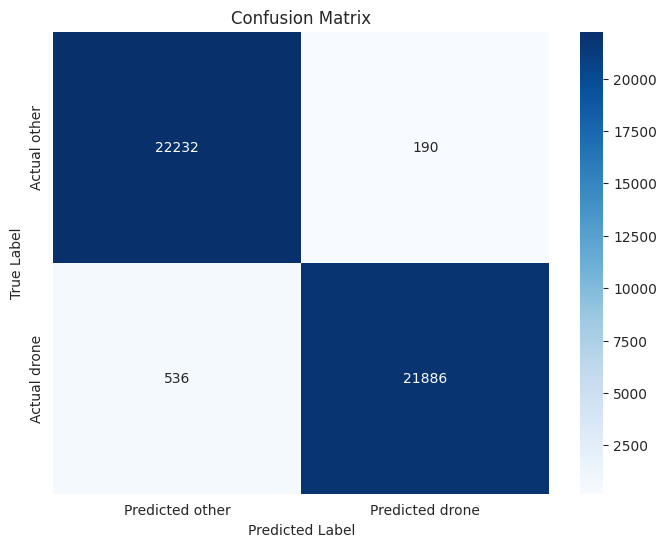


Results DataFrame head:
   true_label  pred_label  confidence
0         0.0         0.0    0.000306
1         0.0         0.0    0.001989
2         0.0         0.0    0.002025
3         0.0         0.0    0.000390
4         1.0         1.0    1.000000


In [11]:

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
target_names = dataset["train"].features["label"].names

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Predicted {target_names[0]}", f"Predicted {target_names[1]}"],
            yticklabels=[f"Actual {target_names[0]}", f"Actual {target_names[1]}"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

df_results = pd.DataFrame({
    "true_label": all_labels,
    "pred_label": all_preds,
    "confidence": all_probs
})

print("\nResults DataFrame head:")
print(df_results.head())

## Evaluation on Custom Test Sets

In [13]:
ds_all_tests = load_dataset("Hibou-Foundation/all_tests_ds_3")

In [14]:
import librosa
def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
     # Convert to log scale (dB)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn_librosa_test(batch):
    inputs = []
    labels = []

    for item in batch:
        waveforme = item["audio"]["array"]
        wave = convert_to_mel_spectrogram(waveforme)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    labels = torch.tensor(labels, dtype=torch.float32)

    return inputs, labels

In [15]:
dataloaders = {}
for split in ds_all_tests.keys():
    ds = ds_all_tests[split]
    dataloaders[split] = DataLoader(
        ds,
        batch_size=1,
        shuffle=False,
        num_workers=1,
        collate_fn=collate_fn_librosa_test,
    )
dataloaders

{'drone_test': <torch.utils.data.dataloader.DataLoader at 0x7f5ca82168b0>,
 'drone_test_2': <torch.utils.data.dataloader.DataLoader at 0x7f5ca8216b10>,
 'parabole1': <torch.utils.data.dataloader.DataLoader at 0x7f5e13c36690>,
 'parabole2': <torch.utils.data.dataloader.DataLoader at 0x7f5ca837dd00>,
 'parabole3': <torch.utils.data.dataloader.DataLoader at 0x7f5e2a5d4e20>,
 'parabole4': <torch.utils.data.dataloader.DataLoader at 0x7f5dd2d91950>,
 'parabole5': <torch.utils.data.dataloader.DataLoader at 0x7f5e2a761c50>,
 'parabole6': <torch.utils.data.dataloader.DataLoader at 0x7f5e2a761e50>,
 'parabole7': <torch.utils.data.dataloader.DataLoader at 0x7f5e2a761d50>}

In [16]:
results = {}
for split, loader in dataloaders.items():
    y_true, y_pred = [], []
    for x, y in tqdm(loader, desc=f"Testing {split}"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred.extend(preds.cpu().numpy().flatten())
        y_true.extend(y.cpu().numpy().flatten())
    results[split] = (y_true, y_pred)

Testing parabole7: 100%|██████████| 7953/7953 [00:22<00:00, 353.80it/s]


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except:
        auc = float("nan")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
    }

metrics = {}
for split, (y_true, y_pred) in results.items():
    metrics[split] = compute_metrics(y_true, y_pred)
    print(split, metrics[split])

drone_test {'accuracy': 0.671892497200448, 'precision': 1.0, 'recall': 0.23697916666666666, 'f1': 0.3831578947368421, 'auc': 0.6184895833333334, 'confusion_matrix': array([[509,   0],
       [293,  91]])}
drone_test_2 {'accuracy': 0.8802139037433155, 'precision': 1.0, 'recall': 0.8801711840228246, 'f1': 0.936267071320182, 'auc': 0.9400855920114123, 'confusion_matrix': array([[   1,    0],
       [ 336, 2468]])}
parabole1 {'accuracy': 0.8536585365853658, 'precision': 0.9838709677419355, 'recall': 0.782051282051282, 'f1': 0.8714285714285714, 'auc': 0.8799145299145298, 'confusion_matrix': array([[44,  1],
       [17, 61]])}
parabole2 {'accuracy': 0.8941176470588236, 'precision': 0.9629629629629629, 'recall': 0.8813559322033898, 'f1': 0.9203539823008849, 'auc': 0.9022164276401564, 'confusion_matrix': array([[24,  2],
       [ 7, 52]])}
parabole3 {'accuracy': 0.44, 'precision': 1.0, 'recall': 0.31555555555555553, 'f1': 0.4797297297297297, 'auc': 0.6577777777777778, 'confusion_matrix': array

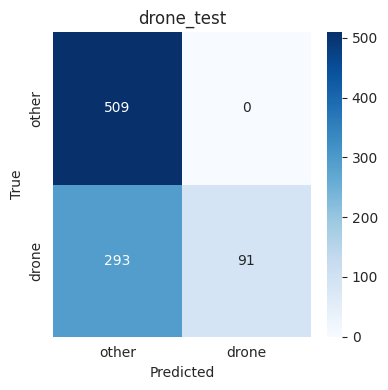

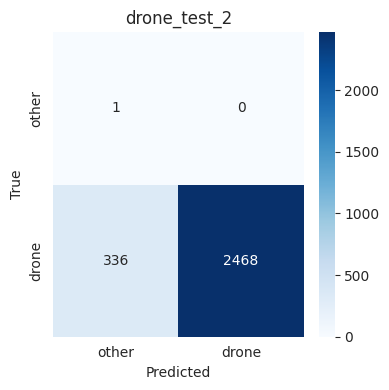

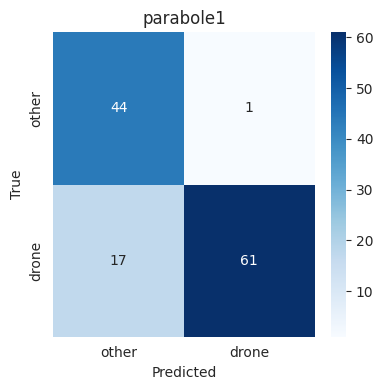

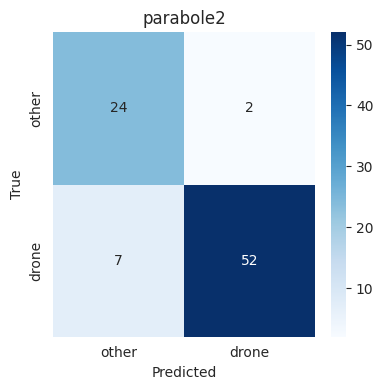

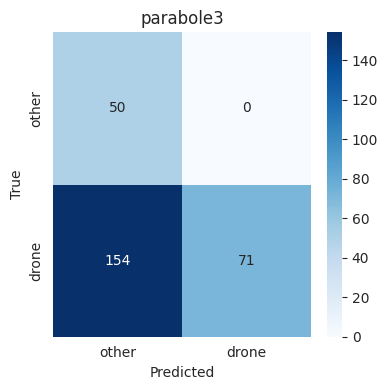

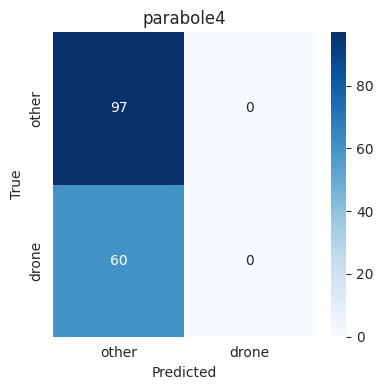

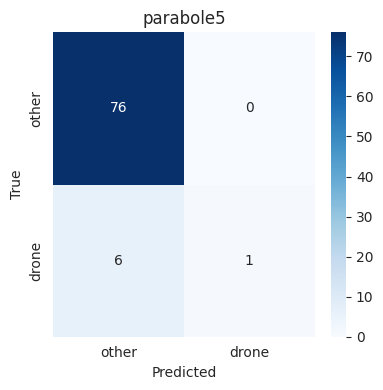

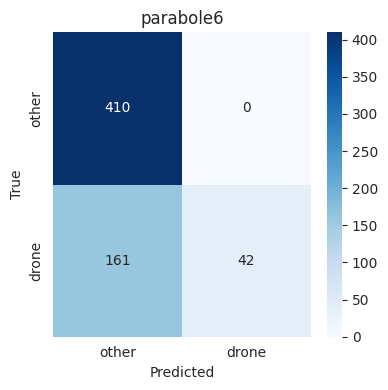

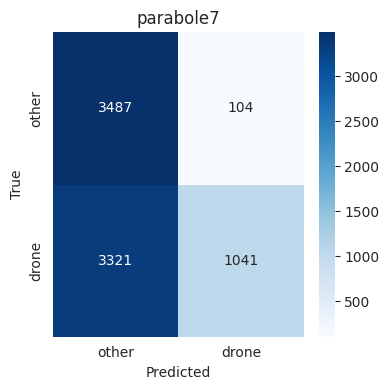

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = ["other", "drone"]

def plot_confusion(cm, title):
    plt.figure(figsize=(4,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for split, metric in metrics.items():
    plot_confusion(metric["confusion_matrix"], split)

## Custom Inference on WAV files

In [ ]:
def infer_from_folder(folder_path: str):
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    results = []
    acc = 0

    for file in files:
        file_path = os.path.join(folder_path, file)
        waveform, sr = librosa.load(file_path, sr=16000)
        mel_spec = convert_to_mel_spectrogram(waveform).unsqueeze(0)
        mel_spec = mel_spec.to(DEVICE)

        with torch.no_grad():
            logits = model(mel_spec)
            probs = torch.sigmoid(logits).squeeze(1)
            pred = (probs > 0.5).float().cpu().item()
            confidence = probs.cpu().item()

        acc += pred
        print(file, int(pred), confidence)
        results.append({
            "file": file,
            "predicted_label": int(pred),
            "confidence": confidence
        })

    print("Acc: ", acc / len(files))

print(f"0 is {"other"}, 1 is {"drone"}")
infer_from_folder("")